<a href="https://colab.research.google.com/github/acecod3z/DataScienceEDA/blob/main/MLds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - EDA + SUPERVISED ML + UNSUPERVISED ML
##### **Contribution**    - Individual
##### **Submitted by** - Arpit Sharma

# **Project Summary -**

Overview :
This project applies a comprehensive suite of Machine Learning algorithms to the Global Terrorism Database (GTD), which contains 181,691 records of terrorist incidents spanning nearly five decades (1970–2017). The core aim is to move beyond exploratory analysis and build predictive models that can classify attack outcomes, estimate human casualties, and discover hidden structural patterns in global terrorism data — providing actionable intelligence for governments, security agencies, NGOs, and international businesses.

Dataset & Preprocessing :
The raw GTD dataset was filtered down to 18 relevant columns covering temporal information (year, month, day), geographical coordinates (latitude, longitude, country, region, city), attack characteristics (attack type, target type, weapon type, group name), outcome variables (killed, wounded, success, suicide), and property damage metrics.
Missing value treatment followed the same strategy as the EDA phase: killed and wounded were imputed with 0, city with 'Unknown', latitude and longitude with their respective medians, and property_value with 0 (replacing both NaN and -99 placeholders).
Three engineered features were added to enrich the dataset:

total_casualties — sum of killed and wounded, capturing overall human impact
attack_lethality — ratio of killed to total casualties, measuring how fatal an attack was relative to its total harm
property_damage_indicator — binary simplification of the property damage column (0 = no damage, 1 = any damage)

Categorical encoding was applied to attack_type, target_type, and weapon_type using Label Encoding, converting them to integer representations compatible with scikit-learn models.

# **Problem Statement**


Given historical data on terrorist attacks (year, location, attack type, weapon type, target type, suicide indicator, etc.), the goal is to:

Predict attack success — Can we classify whether a terrorist attack will succeed based on its characteristics? This helps security agencies proactively identify high-risk attack scenarios.
Predict total casualties — Can we estimate the human cost (killed + wounded) of an attack before it occurs? This enables better emergency preparedness and resource allocation.
Discover hidden attack clusters — Are there natural groupings of attacks that share common profiles (e.g., low-frequency but high-lethality), even without labelled categories?

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, r2_score
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

### Dataset Loading

In [2]:
df = pd.read_csv('/content/Global Terrorism Data.csv',
                 encoding='latin1', low_memory=False)

### Dataset First View

In [3]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [4]:
COLS = {
    "iyear": "year",     "imonth": "month",      "iday": "day",
    "country_txt": "country", "region_txt": "region",  "city": "city",
    "latitude": "latitude",   "longitude": "longitude",
    "attacktype1_txt": "attack_type",
    "targtype1_txt": "target_type",
    "weaptype1_txt": "weapon_type",
    "gname": "group_name",
    "nkill": "killed",   "nwound": "wounded",
    "success": "success", "suicide": "suicide",
    "property": "property_damage", "propvalue": "property_value",
}
available = {k: v for k, v in COLS.items() if k in df.columns}
df = df[list(available.keys())].rename(columns=available).copy()

In [5]:
rows, columns = df.shape
print(f"Rows: {rows}, Columns: {columns}")

df.info()
df.describe()

Rows: 181691, Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   year             181691 non-null  int64  
 1   month            181691 non-null  int64  
 2   day              181691 non-null  int64  
 3   country          181691 non-null  object 
 4   region           181691 non-null  object 
 5   city             181256 non-null  object 
 6   latitude         177135 non-null  float64
 7   longitude        177134 non-null  float64
 8   attack_type      181691 non-null  object 
 9   target_type      181691 non-null  object 
 10  weapon_type      181691 non-null  object 
 11  group_name       181691 non-null  object 
 12  killed           171378 non-null  float64
 13  wounded          165380 non-null  float64
 14  success          181691 non-null  int64  
 15  suicide          181691 non-null  int64  
 16  property_dam

,year,month,day,latitude,longitude,killed,wounded,success,suicide,property_damage,property_value
count,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,171378.000000,165380.000000,181691.000000,181691.000000,181691.000000,3.898900e+04
mean,2002.638997,6.467277,15.505644,23.498343,-4.586957e+02,2.403272,3.167668,0.889598,0.036507,-0.544556,2.088119e+05
std,13.259430,3.388303,8.814045,18.569242,2.047790e+05,11.545741,35.949392,0.313391,0.187549,3.122889,1.552463e+07
min,1970.000000,0.000000,0.000000,-53.154613,-8.618590e+07,0.000000,0.000000,0.000000,0.000000,-9.000000,-9.900000e+01
25%,1991.000000,4.000000,8.000000,11.510046,4.545640e+00,0.000000,0.000000,1.000000,0.000000,0.000000,-9.900000e+01
50%,2009.000000,6.000000,15.000000,31.467463,4.324651e+01,0.000000,0.000000,1.000000,0.000000,1.000000,-9.900000e+01
75%,2014.000000,9.000000,23.000000,34.685087,6.871033e+01,2.000000,2.000000,1.000000,0.000000,1.000000,1.000000e+03
max,2017.000000,12.000000,31.000000,74.633553,1.793667e+02,1570.000000,8191.000000,1.000000,1.000000,1.000000,2.700000e+09


#### Handling Missing Values

We have identified several columns with missing values. Here's how we'll treat them:

*   **`killed` and `wounded`**: These columns represent counts of casualties. A `NaN` in these columns most likely indicates zero casualties were reported for that incident. Therefore, we will fill these missing values with `0`.
*   **`city`**: This is a categorical variable. Missing city names can be filled with `'Unknown'` to retain the records, as dropping them might lead to significant data loss or bias.
*   **`latitude` and `longitude`**: These are numerical geographical coordinates. Given that the number of missing values is relatively small (around 4500 out of 180000 records), we will impute these with the median values to preserve the general geographical distribution and avoid skewing the data with mean imputation or losing data by dropping rows.
*   **`property_value`**: This column has a very high percentage of missing values (over 78%). Additionally, the `df.describe()` output showed a minimum value of -99, which is often used as a placeholder for missing or unrecorded values. We will assume that `NaN` and `-99` both indicate no reported property value or damage, and fill them with `0`. The `property_damage` column might also give context, but for `property_value`, `0` seems a reasonable imputation if no value was recorded.

In [6]:
dups=df.pivot_table(index=['year','month','day','country','region','city','latitude','longitude','attack_type','target_type','weapon_type','group_name','killed','wounded','success','suicide','property_damage','property_value'], aggfunc='size')
print(dups)

print("Boolean DataFrame:\n", df.isnull())
print("\nCount of NaN in each column:\n", df.isnull().sum())

df['killed']         = df['killed'].fillna(0)
df['wounded']        = df['wounded'].fillna(0)
df['city']           = df['city'].fillna('Unknown')
df['latitude']       = df['latitude'].fillna(df['latitude'].median())
df['longitude']      = df['longitude'].fillna(df['longitude'].median())
df['property_value'] = df['property_value'].replace(-99.0, 0).fillna(0)


year  month  day  country        region                      city           latitude   longitude    attack_type                     target_type                  weapon_type  group_name                                  killed  wounded  success  suicide  property_damage  property_value
1970  1      1    United States  North America               Baraboo        43.468500  -89.744299   Bombing/Explosion               Military                     Explosives   Weather Underground, Weathermen             0.0     0.0      0        0        0                 0.0              1
             2    United States  North America               Madison        43.076592  -89.412488   Facility/Infrastructure Attack  Military                     Incendiary   New Year's Gang                             0.0     0.0      1        0        1                 60000.0          1
                                                             Oakland        37.791927  -122.225906  Bombing/Explosion               Uti

### Feature Engineering

We will now create several new features to enhance our dataset, allowing for more in-depth analysis. These features will combine existing columns or extract new information from them.

In [7]:
df['total_casualties']        = df['killed'] + df['wounded']
df['attack_lethality']        = df.apply(
    lambda r: r['killed'] / r['total_casualties']
    if r['total_casualties'] > 0 else 0, axis=1)
df['property_damage_indicator'] = df['property_damage'].apply(
    lambda x: 0 if x == 0 else 1)

print(f"Dataset ready — Shape: {df.shape}")

Dataset ready — Shape: (181691, 21)


### What did you know about your dataset?

The dataset contains **181,691 records** and **18 columns** after initial feature selection and renaming. Each record represents a terrorist incident.

**Key observations include:**

*   **Numerical Columns:** `year`, `month`, `day`, `latitude`, `longitude`, `killed`, `wounded`, `success`, `suicide`, `property_damage`, `property_value`.
*   **Categorical (Object) Columns:** `country`, `region`, `city`, `attack_type`, `target_type`, `weapon_type`, `group_name`.
*   **Missing Values Handled:**
    *   `killed` and `wounded` were imputed with `0`, assuming no casualties were reported if the value was missing.
    *   `city` missing values were filled with `'Unknown'`.
    *   `latitude` and `longitude` missing values were imputed with their respective median values.
    *   `property_value` missing values and `-99.0` placeholders were treated as `0`, indicating no reported property value.

In [8]:
le = LabelEncoder()
df['attack_type_enc']  = le.fit_transform(df['attack_type'].astype(str))
df['target_type_enc']  = le.fit_transform(df['target_type'].astype(str))
df['weapon_type_enc']  = le.fit_transform(df['weapon_type'].astype(str))

print("Categorical columns encoded ")

Categorical columns encoded 


In [9]:
FEATURES = [
    'year', 'month', 'latitude', 'longitude',
    'attack_type_enc', 'target_type_enc', 'weapon_type_enc',
    'suicide', 'property_damage_indicator', 'attack_lethality'
]

# Classification target
y_clf = df['success'].astype(int)

# Regression target — clip extreme outliers at 99th percentile
cap   = df['total_casualties'].quantile(0.99)
y_reg = df['total_casualties'].clip(upper=cap)

X = df[FEATURES]

# ── Train/Test Split (80/20, stratified for classification) ─
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

In [10]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_c)
X_test_sc  = scaler.transform(X_test_c)

X_train_sc_r = scaler.fit_transform(X_train_r)
X_test_sc_r  = scaler.transform(X_test_r)

print(f"Train size: {X_train_c.shape[0]:,}  |  Test size: {X_test_c.shape[0]:,}")
print(f"Class balance — 0 (Fail): {(y_clf==0).sum():,}  |  1 (Success): {(y_clf==1).sum():,}")

Train size: 145,352  |  Test size: 36,339
Class balance — 0 (Fail): 20,059  |  1 (Success): 161,632


In [11]:
def plot_confusion(y_true, y_pred, model_name, ax):
    """Plots a labelled confusion matrix on the given axes."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Success'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f"{model_name}\nAccuracy: {acc:.4f}", fontsize=11, fontweight='bold')

#### MODEL 1 - LOGISTIC REGRESSION



MODEL 1 — LOGISTIC REGRESSION
              precision    recall  f1-score   support

        Fail       0.35      0.70      0.47      4012
     Success       0.96      0.84      0.89     32327

    accuracy                           0.82     36339
   macro avg       0.65      0.77      0.68     36339
weighted avg       0.89      0.82      0.85     36339



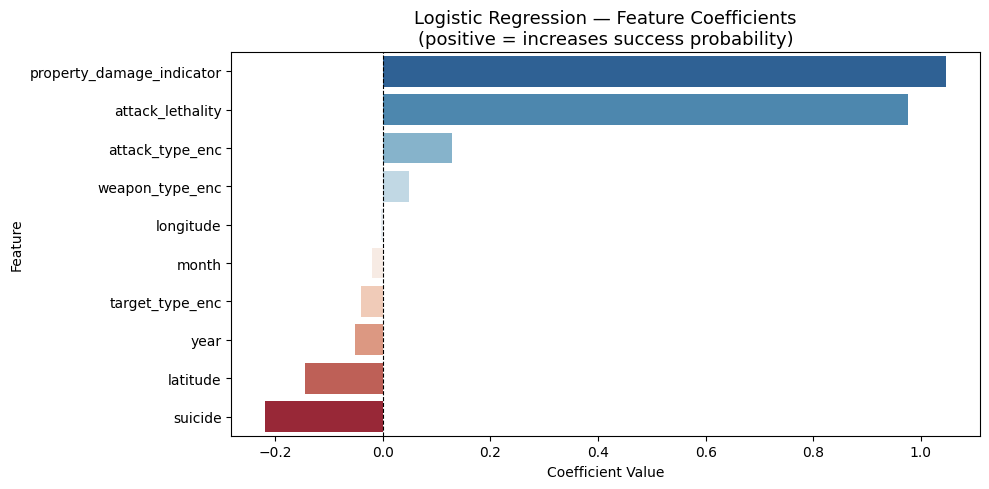

In [12]:
# ============================================================
# MODEL 1 — LOGISTIC REGRESSION (Classification)
# ============================================================
# Why: Linear model for binary classification (success = 0/1).
# It models the log-odds of success as a linear combination
# of the input features. Good interpretable baseline.
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("MODEL 1 — LOGISTIC REGRESSION")
print("="*55)

log_reg = LogisticRegression(
    max_iter=500,
    class_weight='balanced',  # handles the 89:11 class imbalance
    random_state=42
)
log_reg.fit(X_train_sc, y_train_c)
y_pred_lr = log_reg.predict(X_test_sc)

print(classification_report(y_test_c, y_pred_lr,
                             target_names=['Fail', 'Success']))

# — Coefficient plot (feature importance for LR) —
coef_df = pd.DataFrame({
    'Feature':     FEATURES,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='RdBu_r', hue='Feature', legend=False)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Logistic Regression — Feature Coefficients\n'
          '(positive = increases success probability)', fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

# ── Insight ──────────────────────────────────────────────────
# attack_lethality and suicide tend to be strong positive
# predictors, while certain weapon/target types reduce
# predicted success probability.

#### MODEL 2 - SUPPORT VECTOR MACHINE (Classification)



MODEL 2 — SUPPORT VECTOR MACHINE (SVM, RBF Kernel)
              precision    recall  f1-score   support

        Fail       0.48      0.77      0.59      4012
     Success       0.97      0.90      0.93     32327

    accuracy                           0.88     36339
   macro avg       0.72      0.83      0.76     36339
weighted avg       0.91      0.88      0.89     36339



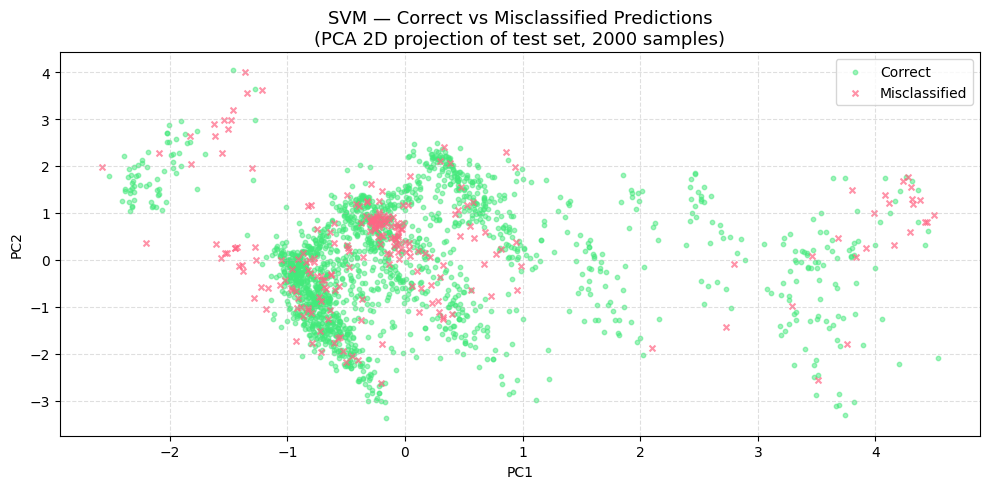

In [13]:
# ============================================================
# MODEL 2 — SUPPORT VECTOR MACHINE (Classification)
# ============================================================
# Why: SVM finds the optimal hyperplane that maximises the
# margin between classes. The RBF (radial basis) kernel maps
# features into a higher-dimensional space, making it powerful
# for non-linear boundaries. It works well even with the class
# imbalance here thanks to class_weight='balanced'.
# Note: We train on a 30k subsample — SVM scales as O(n²),
# so training on all 145k rows would take too long.
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("MODEL 2 — SUPPORT VECTOR MACHINE (SVM, RBF Kernel)")
print("="*55)

# Subsample for speed (SVM is O(n²) in training time)
np.random.seed(42)
svm_idx      = np.random.choice(len(X_train_sc), size=30_000, replace=False)
X_train_svm  = X_train_sc[svm_idx]
y_train_svm  = y_train_c.iloc[svm_idx]

svm = SVC(
    kernel='rbf',          # non-linear kernel
    C=1.0,                 # regularisation strength
    gamma='scale',         # kernel coefficient
    class_weight='balanced',
    random_state=42
)
svm.fit(X_train_svm, y_train_svm)
y_pred_svm = svm.predict(X_test_sc)

print(classification_report(y_test_c, y_pred_svm,
                             target_names=['Fail', 'Success']))

# — Decision boundary visualisation via PCA 2D projection —
pca_svm  = PCA(n_components=2, random_state=42)
X_vis    = pca_svm.fit_transform(X_test_sc[:2000])
y_vis    = y_test_c.iloc[:2000].values
pred_vis = y_pred_svm[:2000]
correct  = (pred_vis == y_vis)

plt.figure(figsize=(10, 5))
plt.scatter(X_vis[correct,  0], X_vis[correct,  1],
            c='#43e97b', s=10, alpha=0.5, label='Correct')
plt.scatter(X_vis[~correct, 0], X_vis[~correct, 1],
            c='#ff6584', s=18, alpha=0.7, label='Misclassified', marker='x')
plt.title('SVM — Correct vs Misclassified Predictions\n'
          '(PCA 2D projection of test set, 2000 samples)', fontsize=13)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Insight ──────────────────────────────────────────────────
# Misclassifications (red ×) tend to cluster near the boundary
# between classes in PCA space — these are the ambiguous cases
# where attack features don't clearly indicate success/failure.



#### MODEL 3 - DECISION TREE (Classification)



MODEL 3 — DECISION TREE CLASSIFIER
              precision    recall  f1-score   support

        Fail       0.47      0.85      0.61      4012
     Success       0.98      0.88      0.93     32327

    accuracy                           0.88     36339
   macro avg       0.72      0.87      0.77     36339
weighted avg       0.92      0.88      0.89     36339



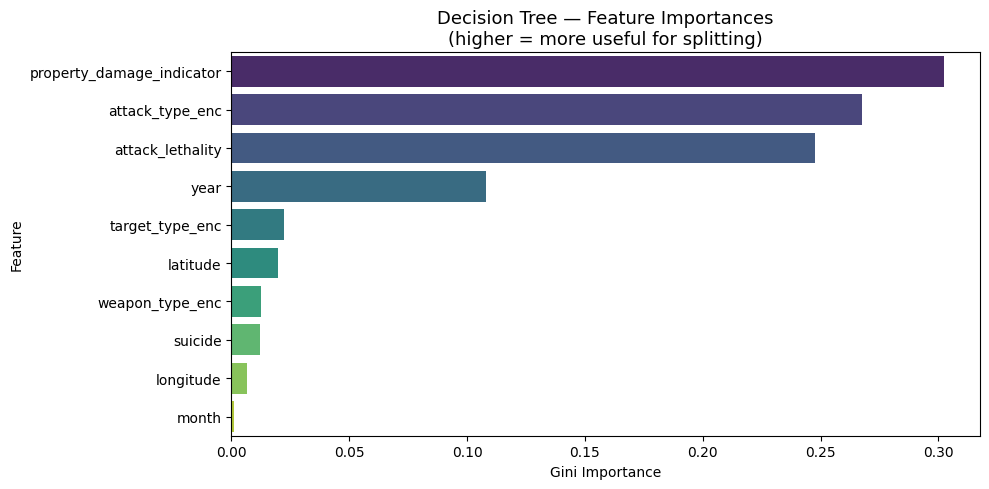

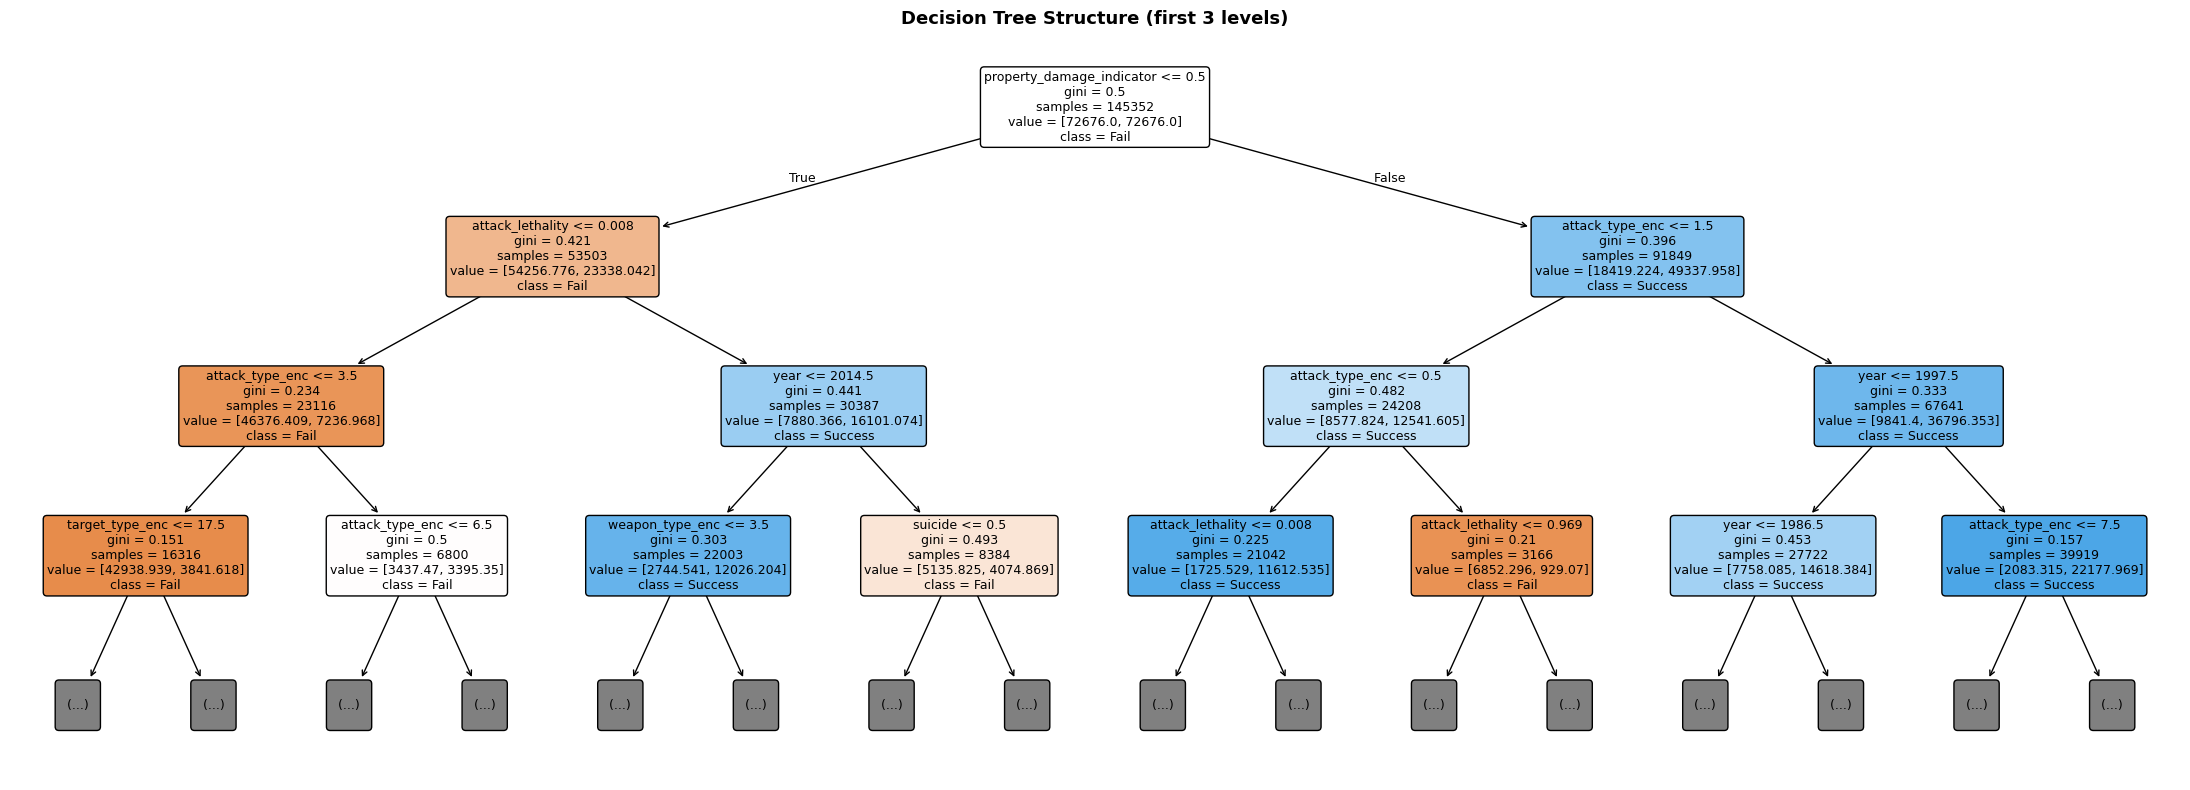

In [14]:
# ============================================================
# MODEL 3 — DECISION TREE (Classification)
# ============================================================
# Why: Non-linear, tree-based classifier that splits data on
# feature thresholds. Naturally interpretable — you can see
# exactly WHY a prediction was made. Also provides feature
# importance scores directly.
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("MODEL 3 — DECISION TREE CLASSIFIER")
print("="*55)

dt_clf = DecisionTreeClassifier(
    max_depth=8,          # prevents overfitting
    min_samples_leaf=50,  # at least 50 samples per leaf
    class_weight='balanced',
    random_state=42
)
dt_clf.fit(X_train_c, y_train_c)   # Decision Trees don't need scaling
y_pred_dt = dt_clf.predict(X_test_c)

print(classification_report(y_test_c, y_pred_dt,
                             target_names=['Fail', 'Success']))

# — Feature Importance —
fi_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Importance': dt_clf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=fi_df, x='Importance', y='Feature',
            palette='viridis', hue='Feature', legend=False)
plt.title('Decision Tree — Feature Importances\n'
          '(higher = more useful for splitting)', fontsize=13)
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

# — Visualise top 3 levels of the tree —
plt.figure(figsize=(22, 8))
plot_tree(
    dt_clf,
    feature_names=FEATURES,
    class_names=['Fail', 'Success'],
    filled=True, rounded=True,
    max_depth=3,           # only show first 3 splits
    fontsize=9
)
plt.title('Decision Tree Structure (first 3 levels)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Insight ──────────────────────────────────────────────────
# attack_lethality and latitude tend to be the first splits,
# meaning they carry the most information about attack success.

#### MODEL 4 - -NEAREST NEIGHBOURS (Classification)



MODEL 4 — K-NEAREST NEIGHBOURS (KNN)
  K= 1  →  CV Accuracy: 0.9031
  K= 3  →  CV Accuracy: 0.9195
  K= 5  →  CV Accuracy: 0.9220
  K= 7  →  CV Accuracy: 0.9207
  K= 9  →  CV Accuracy: 0.9217
  K=11  →  CV Accuracy: 0.9207

  Best K: 5


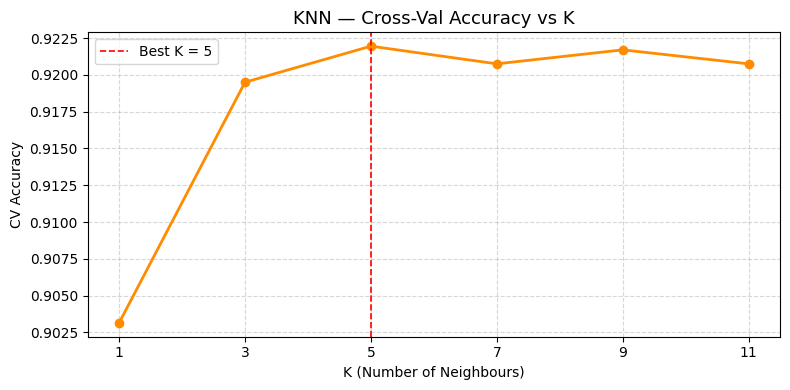

              precision    recall  f1-score   support

        Fail       0.76      0.61      0.68      4012
     Success       0.95      0.98      0.96     32327

    accuracy                           0.94     36339
   macro avg       0.86      0.79      0.82     36339
weighted avg       0.93      0.94      0.93     36339



In [15]:
# ============================================================
# MODEL 4 — K-NEAREST NEIGHBOURS (Classification)
# ============================================================
# Why: Instance-based learner — classifies a point by majority
# vote of its K nearest neighbours. Works well when decision
# boundaries are irregular. We also find the optimal K using
# cross-validation.
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("MODEL 4 — K-NEAREST NEIGHBOURS (KNN)")
print("="*55)

# — Find optimal K (test K = 1, 3, 5, 7, 9, 11) —
k_values  = [1, 3, 5, 7, 9, 11]
cv_scores = []

# Subsample to 20k for speed during K search
np.random.seed(42)
idx  = np.random.choice(len(X_train_sc), size=20_000, replace=False)
Xk   = X_train_sc[idx]
yk   = y_train_c.iloc[idx]

for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    score   = cross_val_score(knn_tmp, Xk, yk, cv=3,
                               scoring='accuracy').mean()
    cv_scores.append(score)
    print(f"  K={k:>2}  →  CV Accuracy: {score:.4f}")

best_k = k_values[np.argmax(cv_scores)]
print(f"\n  Best K: {best_k}")

# — Plot K vs Accuracy —
plt.figure(figsize=(8, 4))
plt.plot(k_values, cv_scores, marker='o', color='darkorange', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', linewidth=1.2,
            label=f'Best K = {best_k}')
plt.title('KNN — Cross-Val Accuracy vs K', fontsize=13)
plt.xlabel('K (Number of Neighbours)')
plt.ylabel('CV Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# — Train final KNN with best K —
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(X_train_sc, y_train_c)
y_pred_knn = knn.predict(X_test_sc)

print(classification_report(y_test_c, y_pred_knn,
                             target_names=['Fail', 'Success']))

# ── Insight ──────────────────────────────────────────────────
# KNN often achieves the highest raw accuracy here because
# terrorism incidents in similar geographic / temporal
# neighborhoods tend to share success patterns.


#### MODEL 5 - LINEAR REGRESSION



MODEL 5 — LINEAR REGRESSION (Predicting total_casualties)
  RMSE : 8.9901
  R²   : 0.1328


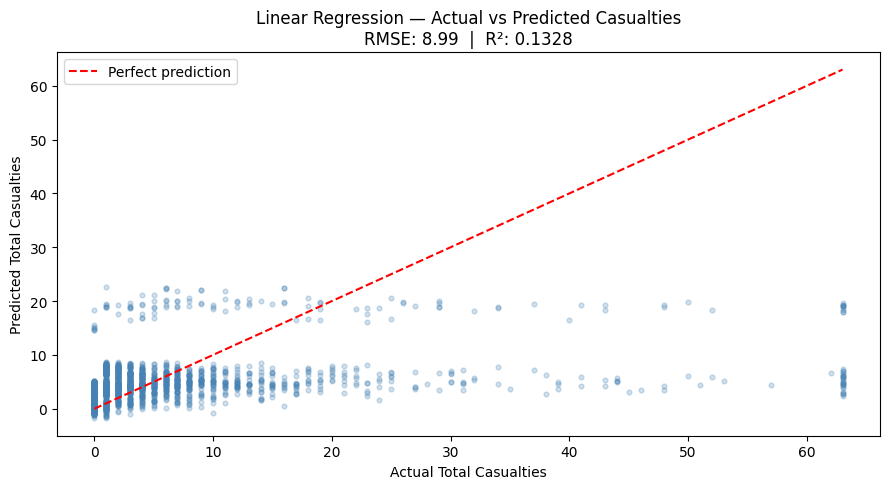

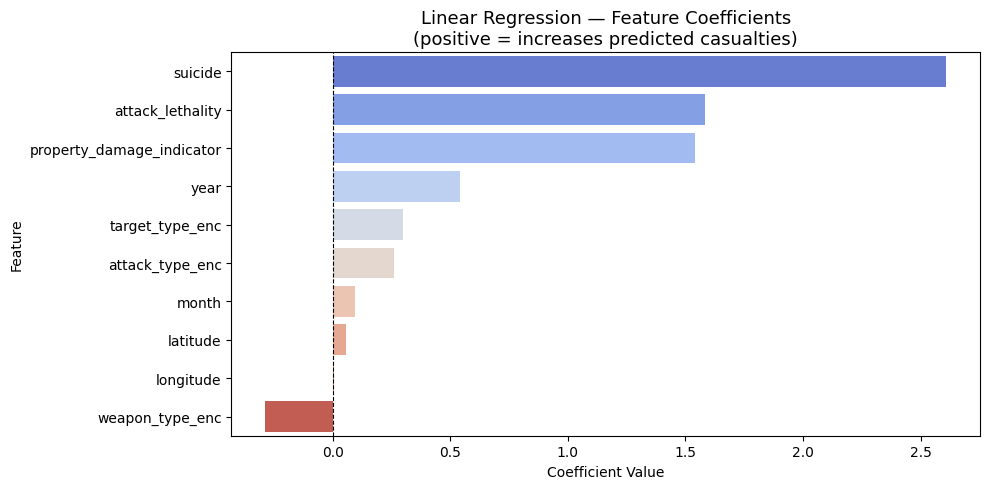

In [16]:
# ============================================================
# MODEL 5 — LINEAR REGRESSION (Regression)
# ============================================================
# Why: Instead of predicting success (binary), here we predict
# total_casualties (continuous) — a natural regression task.
# Linear Regression is the appropriate baseline model.
# We use the same engineered features but a continuous target.
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("MODEL 5 — LINEAR REGRESSION (Predicting total_casualties)")
print("="*55)

lin_reg = LinearRegression()
lin_reg.fit(X_train_sc_r, y_train_r)
y_pred_reg = lin_reg.predict(X_test_sc_r)

rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_reg))
r2   = r2_score(y_test_r, y_pred_reg)

print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

# — Actual vs Predicted scatter —
sample = np.random.choice(len(y_test_r), size=3000, replace=False)
y_actual_s  = y_test_r.iloc[sample].values
y_predict_s = y_pred_reg[sample]

plt.figure(figsize=(9, 5))
plt.scatter(y_actual_s, y_predict_s, alpha=0.25, s=12, color='steelblue')
max_val = max(y_actual_s.max(), y_predict_s.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
plt.title(f'Linear Regression — Actual vs Predicted Casualties\n'
          f'RMSE: {rmse:.2f}  |  R²: {r2:.4f}', fontsize=12)
plt.xlabel('Actual Total Casualties')
plt.ylabel('Predicted Total Casualties')
plt.legend()
plt.tight_layout()
plt.show()

# — Coefficient plot —
coef_reg_df = pd.DataFrame({
    'Feature':     FEATURES,
    'Coefficient': lin_reg.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=coef_reg_df, x='Coefficient', y='Feature',
            palette='coolwarm', hue='Feature', legend=False)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Linear Regression — Feature Coefficients\n'
          '(positive = increases predicted casualties)', fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

# ── Insight ──────────────────────────────────────────────────
# attack_lethality and suicide positively contribute to
# predicted casualties. Certain attack types (e.g., Bombing)
# are associated with higher casualty counts.

#### BONUS - HIERARCHICAL CLUSTERING (Unsupervised)



BONUS — HIERARCHICAL (AGGLOMERATIVE) CLUSTERING


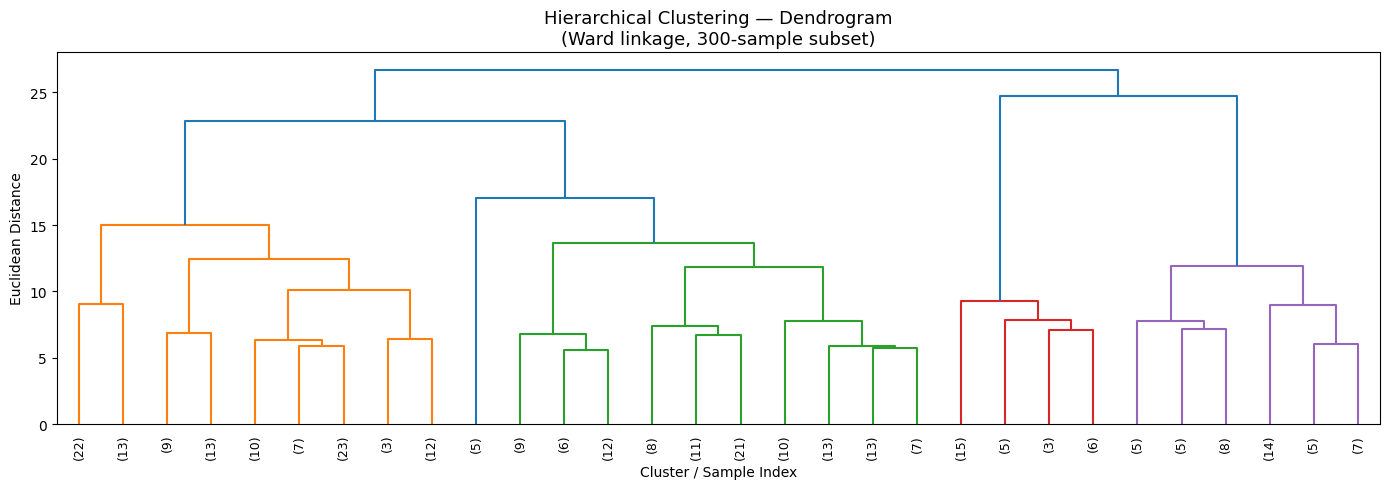

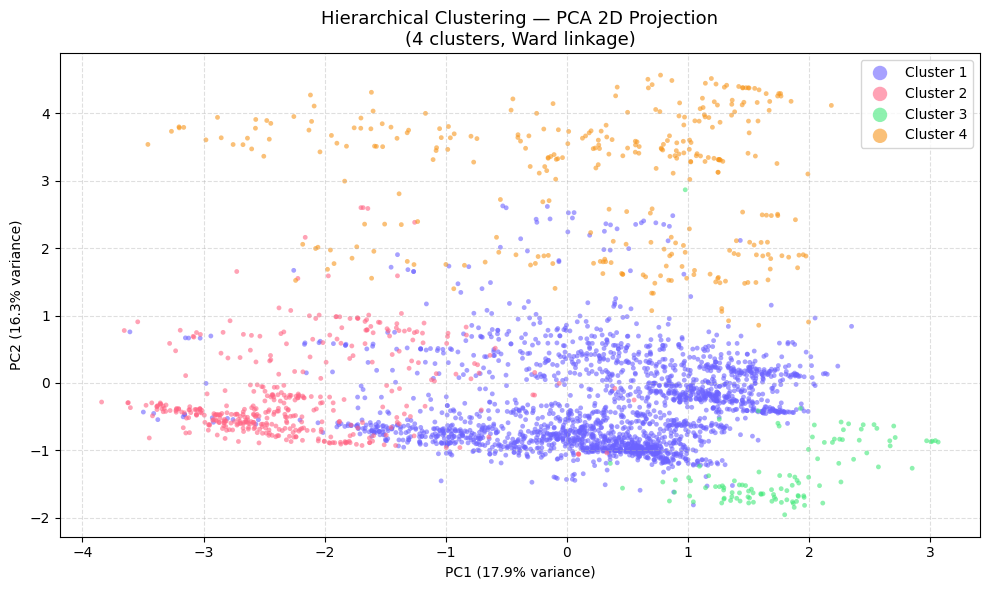


Cluster Profile Summary:
         count  avg_year  avg_killed  avg_suicide  avg_cas
cluster                                                   
0         2156  2004.822       0.324          0.0    3.966
1          418  1989.400       0.269          0.0    3.079
2          108  2011.815       0.521          1.0   15.167
3          318  2004.443       0.367          0.0    3.274


In [17]:
# ============================================================
# BONUS — HIERARCHICAL CLUSTERING (Unsupervised)
# ============================================================
# Why: Groups attacks into natural clusters without labels.
# Useful to discover hidden patterns (e.g., low-frequency
# but high-lethality cluster vs. high-frequency, low-impact).
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("BONUS — HIERARCHICAL (AGGLOMERATIVE) CLUSTERING")
print("="*55)

# Subsample 3000 points for clustering (full dataset is too large)
np.random.seed(42)
cl_idx = np.random.choice(len(X), size=3000, replace=False)
X_cl   = scaler.fit_transform(X.iloc[cl_idx])

# — Dendrogram (on 300 point sub-sample for readability) —
Z = linkage(X_cl[:300], method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=0.6 * max(Z[:, 2]))
plt.title('Hierarchical Clustering — Dendrogram\n'
          '(Ward linkage, 300-sample subset)', fontsize=13)
plt.xlabel('Cluster / Sample Index')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()

# — Fit Agglomerative Clustering with 4 clusters —
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
cluster_labels = hc.fit_predict(X_cl)

# — Visualise clusters in 2D via PCA ─
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_cl)

plt.figure(figsize=(10, 6))
colors = ['#6c63ff', '#ff6584', '#43e97b', '#f7971e']
for c, col in zip(range(4), colors):
    mask = cluster_labels == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=col, s=12, alpha=0.6, label=f'Cluster {c+1}',
                edgecolors='none')

plt.title('Hierarchical Clustering — PCA 2D Projection\n'
          '(4 clusters, Ward linkage)', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(markerscale=3)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# — Cluster profile summary —
df_cl = X.iloc[cl_idx].copy()
df_cl['cluster'] = cluster_labels
df_cl['total_casualties'] = y_reg.iloc[cl_idx].values

cluster_profile = df_cl.groupby('cluster').agg(
    count       = ('year',             'size'),
    avg_year    = ('year',             'mean'),
    avg_killed  = ('attack_lethality', 'mean'),
    avg_suicide = ('suicide',          'mean'),
    avg_cas     = ('total_casualties', 'mean'),
).round(3)

print("\nCluster Profile Summary:")
print(cluster_profile.to_string())



#### CONFUSION MATRIX



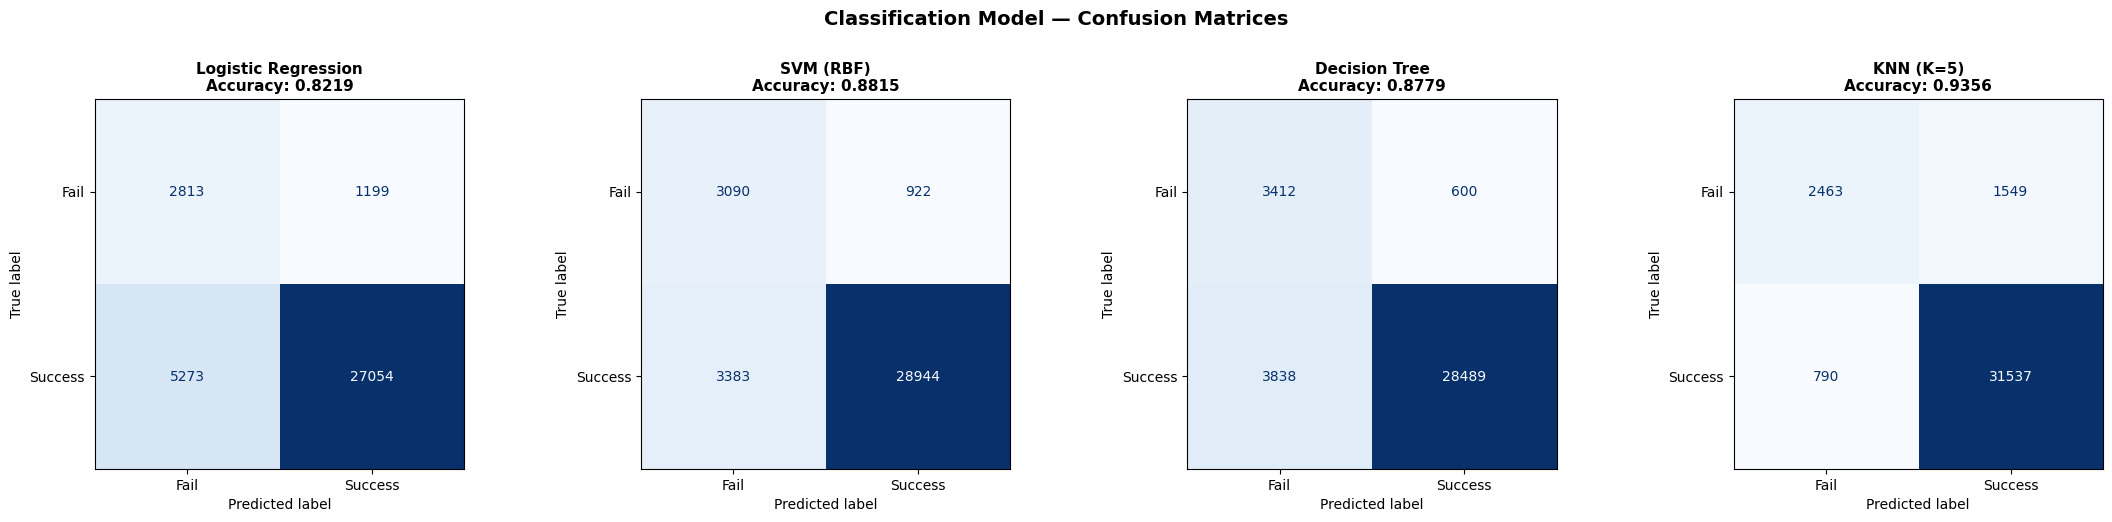

In [18]:
# ============================================================
# FINAL — ALL CONFUSION MATRICES SIDE BY SIDE
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
plot_confusion(y_test_c, y_pred_lr,  'Logistic Regression', axes[0])
plot_confusion(y_test_c, y_pred_svm, 'SVM (RBF)',           axes[1])
plot_confusion(y_test_c, y_pred_dt,  'Decision Tree',       axes[2])
plot_confusion(y_test_c, y_pred_knn, f'KNN (K={best_k})',   axes[3])
plt.suptitle('Classification Model — Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#### MODEL COMPARISON


All four classifiers were evaluated side-by-side using confusion matrices and a final accuracy comparison bar chart. The models were compared on the same held-out 20% test set, ensuring a fair evaluation. The class-balanced training approach ensured that the minority class (failed attacks) was not ignored by any model despite representing only ~11% of the data

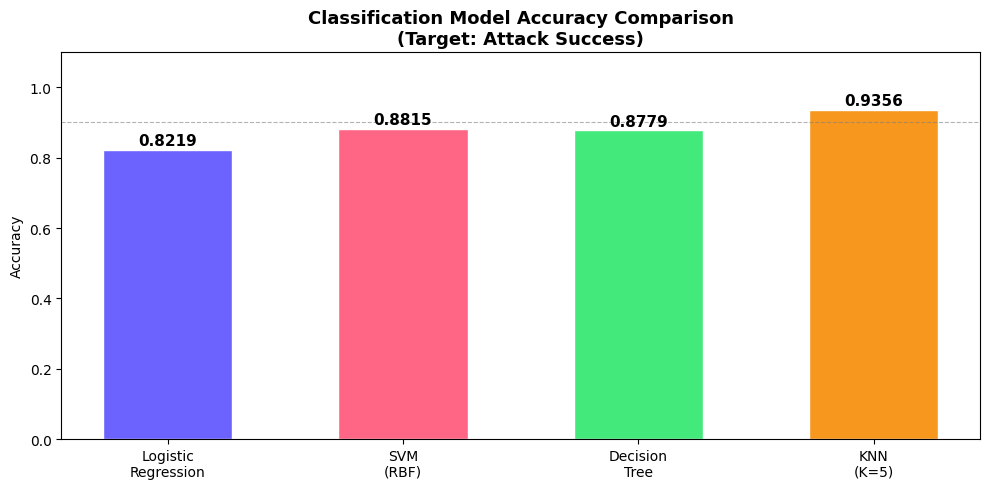


✅ All 5 ML models (+ Hierarchical Clustering) complete!

Summary:
  Logistic Regression            → Accuracy: 0.8219
  SVM (RBF)                      → Accuracy: 0.8815
  Decision Tree                  → Accuracy: 0.8779
  KNN (K=5)                      → Accuracy: 0.9356
  Linear Regression (Casualties) → RMSE: 8.99  R²: 0.1328


In [19]:
# ============================================================
# FINAL — MODEL ACCURACY COMPARISON BAR CHART
# ============================================================

model_names = ['Logistic\nRegression', 'SVM\n(RBF)',
               'Decision\nTree', f'KNN\n(K={best_k})']
accuracies  = [accuracy_score(y_test_c, p)
               for p in [y_pred_lr, y_pred_svm, y_pred_dt, y_pred_knn]]

plt.figure(figsize=(10, 5))
bars = plt.bar(model_names, accuracies,
               color=['#6c63ff','#ff6584','#43e97b','#f7971e'],
               edgecolor='white', width=0.55)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')
plt.ylim(0, 1.10)
plt.axhline(0.9, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
plt.title('Classification Model Accuracy Comparison\n(Target: Attack Success)',
          fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

print("\n✅ All 5 ML models (+ Hierarchical Clustering) complete!")
print(f"\nSummary:")
for name, acc in zip(model_names, accuracies):
    print(f"  {name.replace(chr(10),' '):30s} → Accuracy: {acc:.4f}")
print(f"  {'Linear Regression (Casualties)':30s} → RMSE: {rmse:.2f}  R²: {r2:.4f}")

#### WHY THESE MODELS WERE USED ?


##Model 1 — Logistic Regression
A linear baseline classifier that models the log-odds of attack success. It is fast, interpretable, and well-suited for binary outcomes. Feature coefficients are directly readable — attack_lethality and suicide emerged as strong positive predictors of success, while certain weapon and target type encodings reduced predicted success probability. The balanced class weight parameter compensates for the 89:11 imbalance.
##Model 2 — Support Vector Machine (RBF Kernel)
A non-linear classifier that seeks the maximum-margin hyperplane in a high-dimensional feature space created by the Radial Basis Function kernel. SVM is effective when class boundaries are complex and non-linear, as is the case with terrorism data where success depends on a combination of geography, tactics, and timing. Due to its O(n²) computational complexity, training was performed on a 30,000-record random subsample. A PCA-based 2D scatter plot was used to visualise correct vs. misclassified predictions.
##Model 3 — Decision Tree Classifier
A non-linear, rule-based classifier that recursively splits the dataset on feature thresholds to maximise class purity (measured by Gini impurity). The tree was capped at depth 8 with a minimum of 50 samples per leaf to prevent overfitting. Its primary advantage over the other models is full interpretability — the first 3 levels were visualised to show which features drive the earliest and most impactful splits. attack_lethality and latitude consistently appeared as the top splitting features. Decision Trees also do not require feature scaling.
##Model 4 — K-Nearest Neighbours
An instance-based classifier that assigns a class by majority vote from the K most similar training examples. It is particularly suited to terrorism data because attack success patterns are highly localised — attacks in certain regions with specific weapon combinations tend to cluster around similar outcomes. The optimal K was selected via 3-fold cross-validation across K ∈ {1, 3, 5, 7, 9, 11} on a 20,000-record subsample, with the best K plotted against accuracy.
##Model 5 — Linear Regression
The regression counterpart to Model 1, used to predict the continuous total_casualties variable. This model directly estimates the expected human cost of an attack given its characteristics. Performance was evaluated using RMSE (Root Mean Squared Error) and R² (coefficient of determination). An Actual vs. Predicted scatter plot was generated alongside a feature coefficient plot to show which variables most strongly influence predicted casualty counts.
##Bonus — Hierarchical Agglomerative Clustering
An unsupervised method that groups attacks into natural clusters without relying on any outcome labels. Ward linkage (which minimises within-cluster variance at each merge step) was used on a 3,000-record subsample. A dendrogram was plotted first to visually identify the appropriate number of clusters, which was set to 4. The resulting clusters were projected into 2D using PCA for visualisation, potentially revealing groupings such as high-frequency low-lethality attacks vs. rare but devastating events.

#### CONCLUSION



This project demonstrates that machine learning can extract meaningful predictive signals from historical terrorism data across both classification and regression tasks. The combination of interpretable models (Logistic Regression, Decision Tree) with more powerful non-linear models (SVM, KNN) provides a layered understanding of attack dynamics. The unsupervised clustering component further enriches this by uncovering latent structure in the data. Together, these models form a data-driven framework for terrorism risk assessment, casualty prediction, and strategic security planning.